# Model Selection — Car Price Prediction
This notebook reuses the preprocessing pipeline built in `analysis.ipynb` and performs model selection with hyperparameter tuning to predict car prices.

## 1. Imports

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


## 2. Load Data & Pipeline
We load the raw dataset and the fitted preprocessing pipeline saved from `analysis.ipynb`.


In [124]:
DATA_PATH     = '../data/car_price_dataset_public.csv'
PIPELINE_PATH = '../pipeline.pkl'
df = pd.read_csv(DATA_PATH)

#same cleaning and spliting as in analysis.ipynb
df = df.drop_duplicates(subset=['Car_ID'], keep='first').reset_index(drop=True)
df = df[df['Price'] > 0].reset_index(drop=True)
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

feature_columns = ['Model_Year', 'Mileage', 'Doors', 'Owner_Count',
                   'Horsepower', 'Brand', 'Fuel_Type', 'Transmission', 'Engine_Size']
target_column = 'Price'

X_train = df_train[feature_columns].copy()
y_train = df_train[target_column].copy()
X_test  = df_test[feature_columns].copy()
y_test  = df_test[target_column].copy()



In [125]:
import sys
sys.path.append('../') 

from custom_imputers__class import HorsepowerEngineRatio, HorsepowerImputer, DataCleaner

with open(PIPELINE_PATH, 'rb') as f:
    preprocessor = pickle.load(f)

X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

## 3. Baseline — Quick Comparison (no tuning)
We first fit every candidate model with default settings to establish baseline R² scores and identify the most promising models.

In [126]:
baseline_models = {
    'Linear':               LinearRegression(),
    'Ridge':                Ridge(),
    'Lasso':                Lasso(),
    'ElasticNet':           ElasticNet(),
    'DecisionTree':         DecisionTreeRegressor(random_state=42),
    'RandomForest':         RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting':     GradientBoostingRegressor(random_state=42),
}

baseline_results = []

for name, model in baseline_models.items():
    cv_scores = cross_val_score(model, X_train_proc, y_train, cv=5,
                                scoring='r2', n_jobs=-1)
    model.fit(X_train_proc, y_train)
    y_pred = model.predict(X_test_proc)

    baseline_results.append({
        'Model':    name,
        'CV R² (mean)': round(cv_scores.mean(), 4),
        'CV R² (std)':  round(cv_scores.std(),  4),
        'Test R²':      round(r2_score(y_test, y_pred), 4),
        'Test MAE':     round(mean_absolute_error(y_test, y_pred), 2),
        'Test RMSE':    round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
    })
    print(f'{name:20s}  CV R²={cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

baseline_df = pd.DataFrame(baseline_results).sort_values('CV R² (mean)', ascending=False)
display(baseline_df)

Linear                CV R²=0.7370 ± 0.0149
Ridge                 CV R²=0.7374 ± 0.0142
Lasso                 CV R²=0.7373 ± 0.0147
ElasticNet            CV R²=0.6411 ± 0.0167
DecisionTree          CV R²=0.3267 ± 0.0401
RandomForest          CV R²=0.6824 ± 0.0142
GradientBoosting      CV R²=0.7036 ± 0.0191


,Model,CV R² (mean),CV R² (std),Test R²,Test MAE,Test RMSE
1,Ridge,0.7374,0.0142,0.7006,3779.02,5116.79
2,Lasso,0.7373,0.0147,0.7005,3781.50,5117.65
0,Linear,0.7370,0.0149,0.7003,3785.65,5119.32
6,GradientBoosting,0.7036,0.0191,0.6619,4135.41,5437.48
5,RandomForest,0.6824,0.0142,0.6171,4380.53,5787.09
3,ElasticNet,0.6411,0.0167,0.6287,4523.47,5698.28
4,DecisionTree,0.3267,0.0401,0.3479,5914.66,7551.95


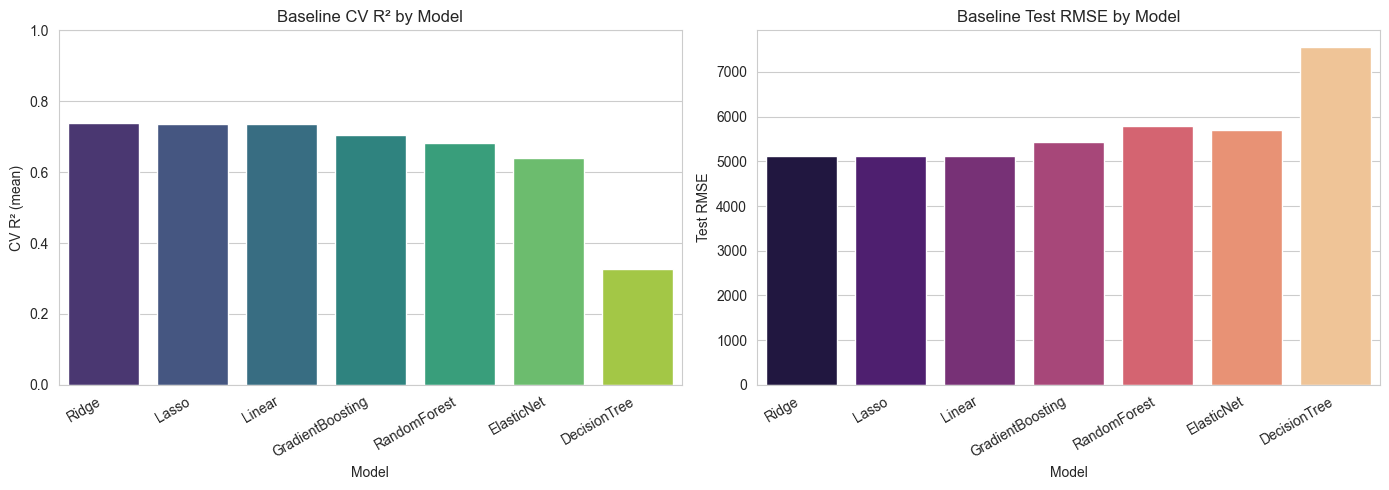

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=baseline_df, x='Model', y='CV R² (mean)', ax=axes[0], palette='viridis')
axes[0].set_title('Baseline CV R² by Model')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].set_ylim(0, 1)

sns.barplot(data=baseline_df, x='Model', y='Test RMSE', ax=axes[1], palette='magma')
axes[1].set_title('Baseline Test RMSE by Model')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

## 4. Hyperparameter Tuning

We tune the **top 3 models** identified in the baseline. 
- Linear models → `GridSearchCV` (small grid, fast)
- Tree ensembles → `RandomizedSearchCV` (large search space)

### 4.1 Ridge

In [128]:
ridge_param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]
}

ridge_gs = GridSearchCV(
    Ridge(),
    ridge_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
ridge_gs.fit(X_train_proc, y_train)

print('Best params :', ridge_gs.best_params_)
print('Best CV R²  :', round(ridge_gs.best_score_, 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params : {'alpha': 10}
Best CV R²  : 0.7378


In [129]:
lasso_param_grid = {
    'alpha':    [0.001, 0.01, 0.1, 1, 10, 100],
    'max_iter': [1000, 5000]
}

lasso_gs = GridSearchCV(
    Lasso(),
    lasso_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
lasso_gs.fit(X_train_proc, y_train)

print('Best params :', lasso_gs.best_params_)
print('Best CV R²  :', round(lasso_gs.best_score_, 4))

lasso_gs

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params : {'alpha': 10, 'max_iter': 1000}
Best CV R²  : 0.738


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...], 'max_iter': [1000, 5000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate pa

In [130]:
gb_param_grid = {
    'n_estimators':     [100, 200, 300],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'max_depth':        [3, 4, 5, 6],
    'subsample':        [0.7, 0.8, 1.0],
    'min_samples_leaf': [1, 3, 5],
}

gb_rs = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
gb_rs.fit(X_train_proc, y_train)

print('Best params :', gb_rs.best_params_)
print('Best CV R²  :', round(gb_rs.best_score_, 4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params : {'subsample': 0.7, 'n_estimators': 100, 'min_samples_leaf': 3, 'max_depth': 3, 'learning_rate': 0.1}
Best CV R²  : 0.7126


## 5. Final Evaluation on the Test Set

In [131]:
tuned_models = {
    'Ridge (tuned)':            ridge_gs.best_estimator_,
    'Lasso (tuned)':            lasso_gs.best_estimator_,
    'GradientBoosting (tuned)': gb_rs.best_estimator_,
}

final_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test_proc)
    final_results.append({
        'Model':     name,
        'Test R²':   round(r2_score(y_test, y_pred), 4),
        'Test MAE':  round(mean_absolute_error(y_test, y_pred), 2),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
    })

final_df = pd.DataFrame(final_results).sort_values('Test R²', ascending=False)
display(final_df)

,Model,Test R²,Test MAE,Test RMSE
0,Ridge (tuned),0.7015,3769.34,5108.91
1,Lasso (tuned),0.7012,3771.92,5111.71
2,GradientBoosting (tuned),0.6733,4016.48,5345.53


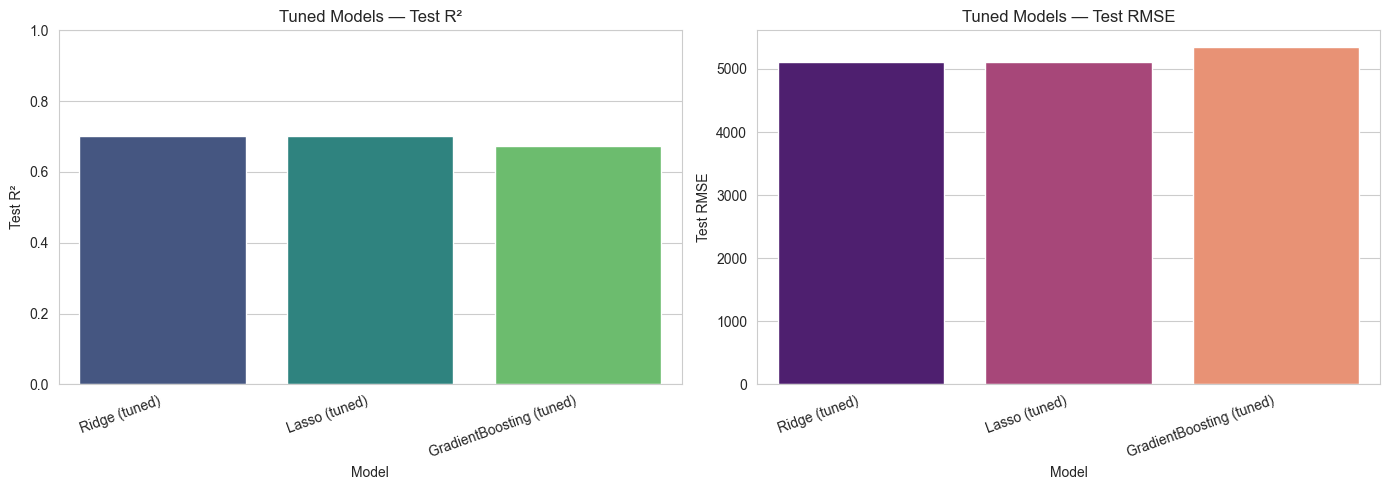

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=final_df, x='Model', y='Test R²', ax=axes[0], palette='viridis')
axes[0].set_title('Tuned Models — Test R²')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
axes[0].set_ylim(0, 1)

sns.barplot(data=final_df, x='Model', y='Test RMSE', ax=axes[1], palette='magma')
axes[1].set_title('Tuned Models — Test RMSE')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

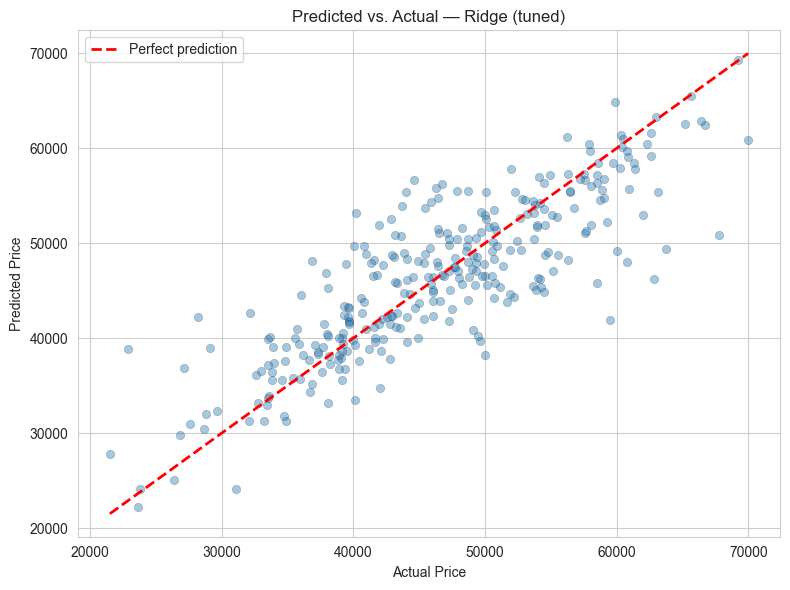

In [133]:
best_name   = final_df.iloc[0]['Model']
best_model  = tuned_models[best_name]
y_pred_best = best_model.predict(X_test_proc)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4, edgecolors='k', linewidths=0.3)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Predicted vs. Actual — {best_name}')
plt.legend()
plt.tight_layout()
plt.show()

In [134]:
search_objects = {
    'Ridge':            ridge_gs,
    'Lasso':            lasso_gs,
    'GradientBoosting': gb_rs,
}

print('=' * 65)
print('          HYPERPARAMETER SELECTION REPORT')
print('=' * 65)

for model_name, search in search_objects.items():
    best_est   = search.best_estimator_
    best_cv_r2 = round(search.best_score_, 4)
    y_pred_    = best_est.predict(X_test_proc)
    test_r2    = round(r2_score(y_test, y_pred_), 4)
    test_rmse  = round(np.sqrt(mean_squared_error(y_test, y_pred_)), 2)
    test_mae   = round(mean_absolute_error(y_test, y_pred_), 2)

    print(f'\n  Model : {model_name}')
    print(f'  Best hyperparameters:')
    for param, val in search.best_params_.items():
        print(f'      {param:25s}: {val}')
    print(f'  CV R²  (5-fold) : {best_cv_r2}')
    print(f'  Test R²         : {test_r2}')
    print(f'  Test MAE        : {test_mae}')
    print(f'  Test RMSE       : {test_rmse}')
    print('-' * 65)

print(f'\n>>> Best overall model: {best_name} (Test R² = {final_df.iloc[0]["Test R²"]})')

          HYPERPARAMETER SELECTION REPORT

  Model : Ridge
  Best hyperparameters:
      alpha                    : 10
  CV R²  (5-fold) : 0.7378
  Test R²         : 0.7015
  Test MAE        : 3769.34
  Test RMSE       : 5108.91
-----------------------------------------------------------------

  Model : Lasso
  Best hyperparameters:
      alpha                    : 10
      max_iter                 : 1000
  CV R²  (5-fold) : 0.738
  Test R²         : 0.7012
  Test MAE        : 3771.92
  Test RMSE       : 5111.71
-----------------------------------------------------------------

  Model : GradientBoosting
  Best hyperparameters:
      subsample                : 0.7
      n_estimators             : 100
      min_samples_leaf         : 3
      max_depth                : 3
      learning_rate            : 0.1
  CV R²  (5-fold) : 0.7126
  Test R²         : 0.6733
  Test MAE        : 4016.48
  Test RMSE       : 5345.53
-----------------------------------------------------------------

>>> B